# Sells analysis — Superstore Dataset

**Objective:** Identifying sells patterns, seasonality and key products to help in decision making.

**Dataset:** 9.800 sell orders | 18 variables | Time period 2014–2017
**Tools:** Python · Pandas · Matplotlib · Seaborn

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

df = pd.read_csv("train.csv")
df["Order Date"] = pd.to_datetime(df["Order Date"], format="%d/%m/%Y")
df["Ship Date"] = pd.to_datetime(df["Ship Date"], format="%d/%m/%Y")
df["year"] = df["Order Date"].dt.year
df["month"] = df["Order Date"].dt.month
df["month_name"] = df["Order Date"].dt.month_name()

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,year,month,month_name
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2017,11,November
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,2017,11,November
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2017,6,June
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,2016,10,October
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2016,10,October


## 1. Dataset overview
The dataset has 9800 rows (inputs) and 18 columns, it keeps all the information of the sells from a store, divinding the products into categories and sub-categories.

There are 9800 sell orders with an average of $230.76 per order, the minimum order value is $0.44 and the maximum $22638.48. The total sells value is $2261536.78

In [3]:
df.info()
df.describe()


<class 'pandas.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9800 non-null   int64         
 1   Order ID       9800 non-null   str           
 2   Order Date     9800 non-null   datetime64[us]
 3   Ship Date      9800 non-null   datetime64[us]
 4   Ship Mode      9800 non-null   str           
 5   Customer ID    9800 non-null   str           
 6   Customer Name  9800 non-null   str           
 7   Segment        9800 non-null   str           
 8   Country        9800 non-null   str           
 9   City           9800 non-null   str           
 10  State          9800 non-null   str           
 11  Postal Code    9789 non-null   float64       
 12  Region         9800 non-null   str           
 13  Product ID     9800 non-null   str           
 14  Category       9800 non-null   str           
 15  Sub-Category   9800 non-null   s

,Row ID,Order Date,Ship Date,Postal Code,Sales,year,month
count,9800.000000,9800,9800,9789.000000,9800.000000,9800.000000,9800.000000
mean,4900.500000,2017-05-01 05:13:51.673469,2017-05-05 04:17:52.653061,55273.322403,230.769059,2016.724184,7.818469
min,1.000000,2015-01-03 00:00:00,2015-01-07 00:00:00,1040.000000,0.444000,2015.000000,1.000000
25%,2450.750000,2016-05-24 00:00:00,2016-05-27 18:00:00,23223.000000,17.248000,2016.000000,5.000000
50%,4900.500000,2017-06-26 00:00:00,2017-06-29 00:00:00,58103.000000,54.490000,2017.000000,9.000000
75%,7350.250000,2018-05-15 00:00:00,2018-05-19 00:00:00,90008.000000,210.605000,2018.000000,11.000000
max,9800.000000,2018-12-30 00:00:00,2019-01-05 00:00:00,99301.000000,22638.480000,2018.000000,12.000000
std,2829.160653,NaN,NaN,32041.223413,626.651875,1.123984,3.281905


## 2. Sells per category

The category Technology generates sells for $827456, it's 11.9% over Furniture and 14.7% over Office Supplies.

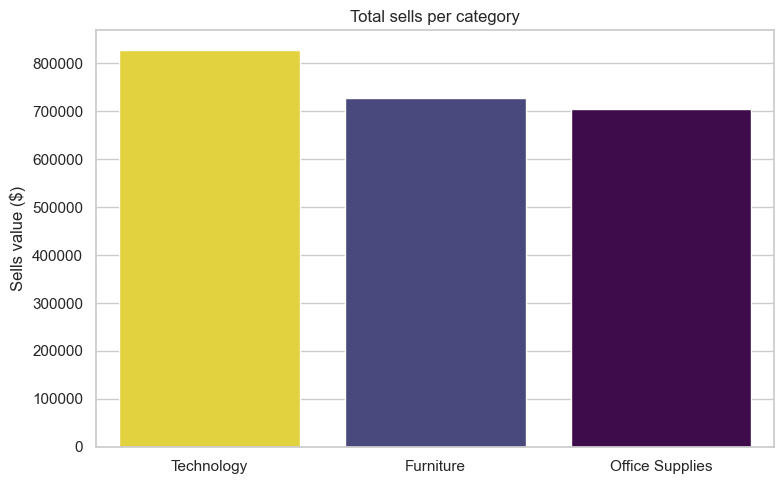

The category Technology generates sells for $827456, it's 11.9% over Furniture and 14.7% over Office Supplies.


In [4]:
sales_category = df.groupby("Category")["Sales"].sum().sort_values(ascending=False)


plt.figure(figsize=(8, 5))
sns.barplot(x=sales_category.index,
            y=sales_category.values,
            hue=sales_category.values,
            palette="viridis",
            legend=False)
plt.title("Total sells per category")
plt.ylabel("Sells value ($)")
plt.xlabel("")
plt.tight_layout()
plt.show()

total_tech = df.groupby("Category")["Sales"].sum()["Technology"]
porcentaje_furn = (df.groupby("Category")["Sales"].sum()["Technology"]-df.groupby("Category")["Sales"].sum()["Furniture"])/df.groupby("Category")["Sales"].sum()["Technology"]*100
porcentaje_office = (df.groupby("Category")["Sales"].sum()["Technology"]-df.groupby("Category")["Sales"].sum()["Office Supplies"])/df.groupby("Category")["Sales"].sum()["Technology"]*100

print(f"The category Technology generates sells for ${total_tech:.0f}, it's {porcentaje_furn:.1f}% over Furniture and {porcentaje_office:.1f}% over Office Supplies.")

## 3. Monthly seasonality

At the beggining of the year (January and February) sells are at minimum levels, at the middle of the year they are average and at the ending they are at maximum levels.
Thers's not much of a variation on the average order value during the year, the increase in total sells during the year comes from an increase in the amount of orders.

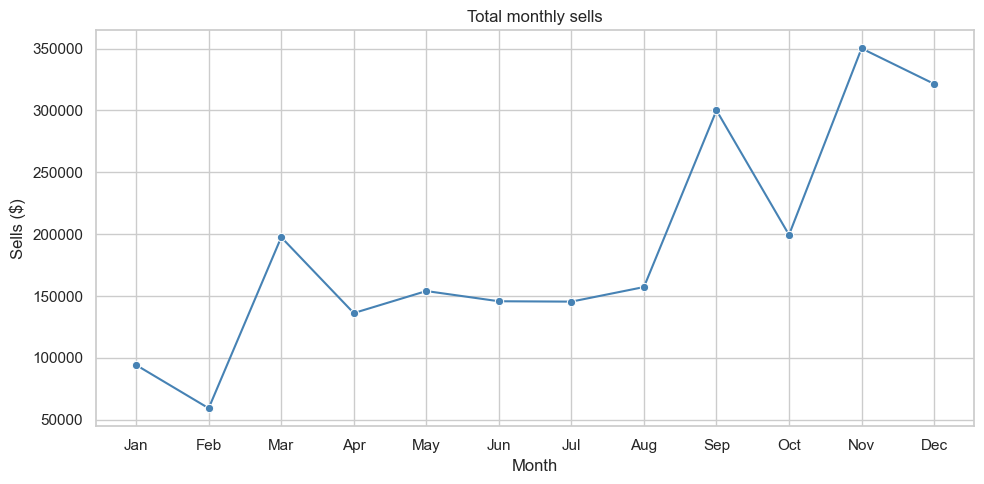

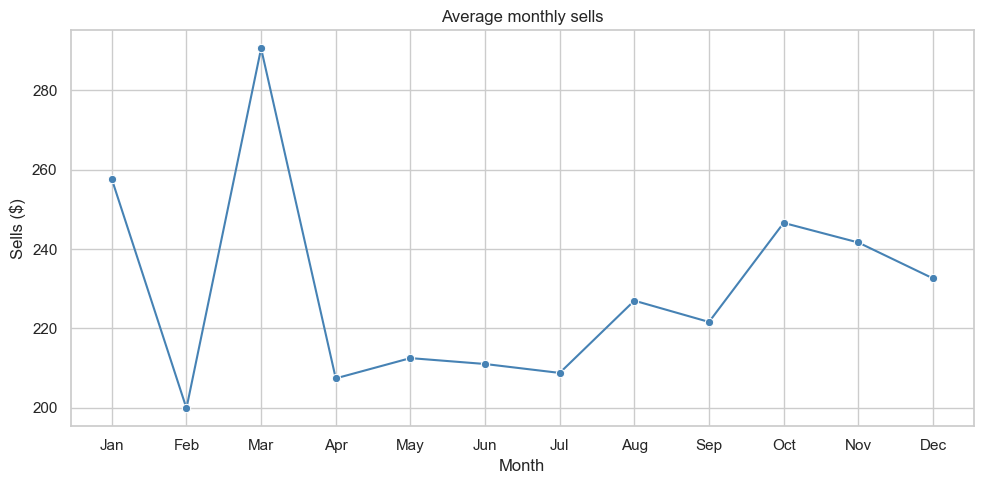

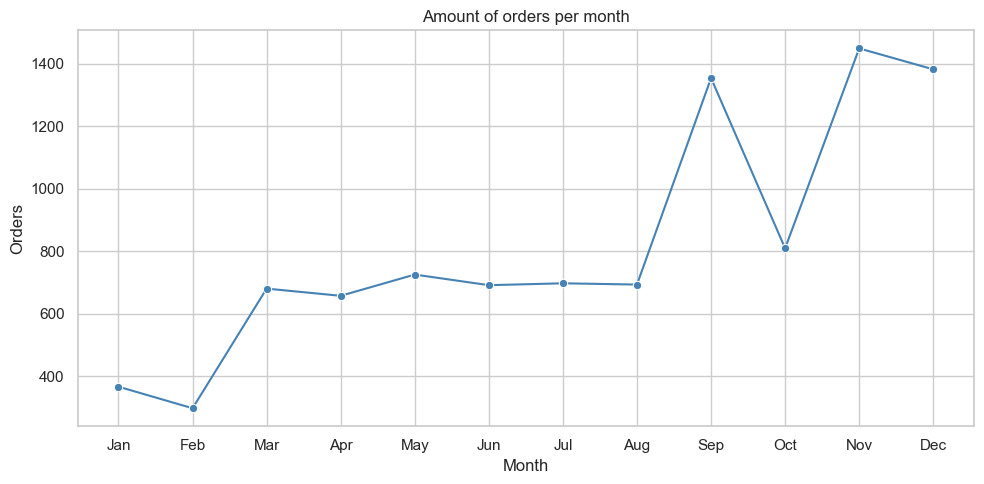

In [5]:
sells_month = df.groupby("month")["Sales"].sum()

plt.figure(figsize=(10, 5))
sns.lineplot(x=sells_month.index, y=sells_month.values, marker="o", color="steelblue")
plt.title("Total monthly sells")
plt.ylabel("Sells ($)")
plt.xlabel("Month")
plt.xticks(range(1, 13), ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"])
plt.tight_layout()
plt.show()

month_average = df.groupby("month")["Sales"].mean()

plt.figure(figsize=(10, 5))
sns.lineplot(x=month_average.index, y=month_average.values, marker="o", color="steelblue")
plt.title("Average monthly sells")
plt.ylabel("Sells ($)")
plt.xlabel("Month")
plt.xticks(range(1, 13), ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"])
plt.tight_layout()
plt.show()

month_amount = df.groupby("month")["Sales"].count()

plt.figure(figsize=(10, 5))
sns.lineplot(x=month_amount.index, y=month_amount.values, marker="o", color="steelblue")
plt.title("Amount of orders per month")
plt.ylabel("Orders")
plt.xlabel("Month")
plt.xticks(range(1, 13), ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"])
plt.tight_layout()
plt.show()

## 4. Average ticket per sub-category

There's great variation on the average tickets of the sub-categories from the store, some are over $1000 and some are less than $15, this doesn't mean that the higher tickets generate more money as we aren't taking into account the amount sold from each category.

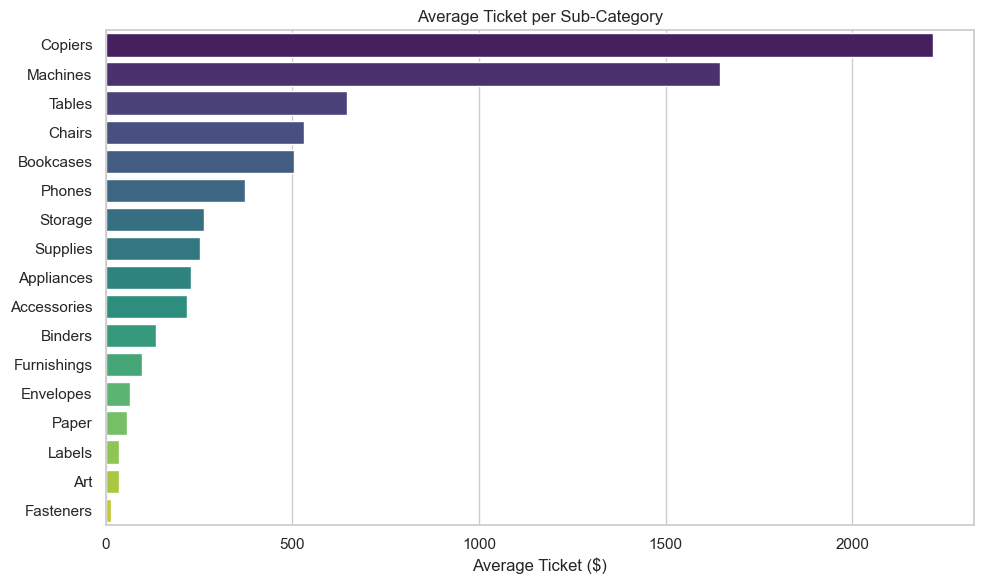

Sub-Category
Accessories     217.178175
Appliances      227.926804
Art              34.019631
Binders         134.067550
Bookcases       503.598224
Chairs          531.833165
Copiers        2215.880212
Envelopes        65.032444
Fasteners        14.027850
Furnishings      95.823865
Labels           34.587468
Machines       1645.553313
Paper            57.420257
Phones          374.180877
Storage         263.633885
Supplies        252.284283
Tables          645.893720
Name: Sales, dtype: float64

In [21]:
ticket_sub = df.groupby("Sub-Category")["Sales"].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=ticket_sub.values, y=ticket_sub.index,hue=ticket_sub.index, palette="viridis",legend=False)
plt.title("Average Ticket per Sub-Category")
plt.xlabel("Average Ticket ($)")
plt.ylabel("")
plt.tight_layout()
plt.show()

df.groupby("Sub-Category")["Sales"].mean()

## 5. Earnings per category

We can see how Phones and Chairs generate the most earnings out of all categories.

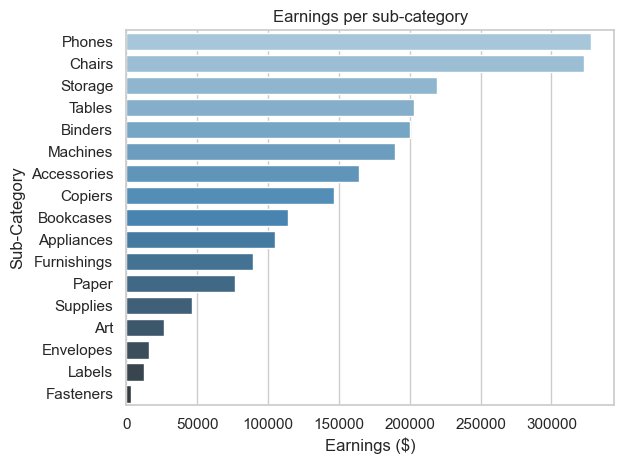

In [7]:
resumen = df.groupby("Sub-Category")["Sales"].agg(
    cantidad="count",
    ticket_promedio="mean"
)

resumen["Earnings"] = resumen["cantidad"] * resumen["ticket_promedio"]
resumen.sort_values("Earnings", ascending=False)

sns.barplot(x=resumen["Earnings"].sort_values(ascending=False),
            y=resumen.sort_values("Earnings", ascending=False).index,
            hue=resumen.sort_values("Earnings", ascending=False).index,
            palette="Blues_d",
            legend=False)
plt.title("Earnings per sub-category")
plt.xlabel("Earnings ($)")
plt.tight_layout()
plt.show()

## 6. Top 5 products

The product that generates the most sells is the Canon imageCLASS 2200 Advanced Copier at $61599.82, it makes more than twice than the next best item.
The product that generates the most sell orders is the Staple envelope, with a total of 47, followed closely by the Staples and the Easy-staple paper.

In [20]:
topsells = df.groupby(["Product Name"])["Sales"].sum().sort_values(ascending=False).head(5)
print(topsells)


sells_amount = df.groupby(["Product Name","Sub-Category"])["Sales"].agg(amount="count",value="sum").sort_values("amount",ascending=False).head(5)
print(sells_amount)

Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
Name: Sales, dtype: float64
                                      amount     value
Product Name            Sub-Category                  
Staple envelope         Envelopes         47  1675.652
Staples                 Fasteners         46   755.470
Easy-staple paper       Paper             44  2414.156
Avery Non-Stick Binders Binders           20   217.316
Staple remover          Supplies          18   263.088


## 7. Sells per region

We can see how most sells come from the West and East, the South generates almost half the sells that the West does.

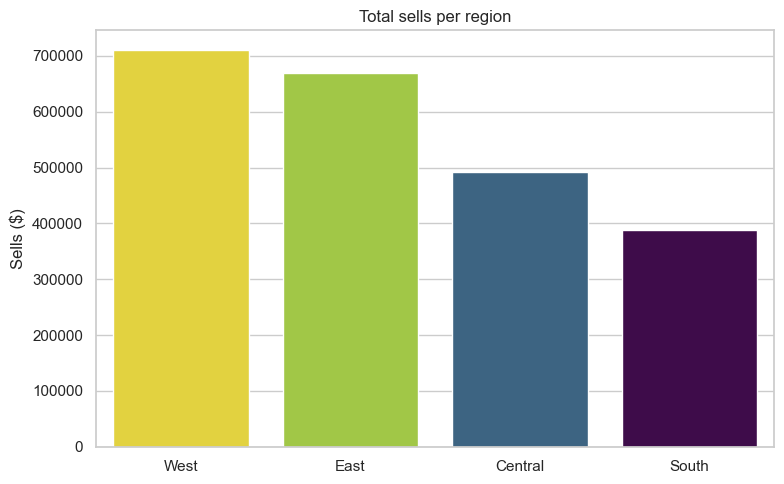

Region
West       710219.6845
East       669518.7260
Central    492646.9132
South      389151.4590
Name: Sales, dtype: float64


In [28]:
region_sells = df.groupby("Region")["Sales"].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=region_sells.index,
            y=region_sells.values,
            hue=region_sells.values,
            palette="viridis",
            legend=False)
plt.title("Total sells per region")
plt.ylabel("Sells ($)")
plt.xlabel("")
plt.tight_layout()
plt.show()

print(region_sells)

## 8. Same Day Shipping

60% of all Same Day Shippings are for the Office Supplies category, meaning their products are more important to have rigth away.

In [29]:
sameday = df[df["Ship Mode"] == "Same Day"]

sameday.groupby("Category")["Ship Mode"].count()
conteo = sameday.groupby("Category")["Ship Mode"].count()
print(conteo / conteo.sum())

Category
Furniture          0.219331
Office Supplies    0.600372
Technology         0.180297
Name: Ship Mode, dtype: float64


## Conclusions

- There was high seasonality in the amount of orders, it was much higher at the end of the year, but the average order value didn't have big variations.
- The West region leads with $710K in sales, nearly double the South region ($389K)
- The product that generated the most income was the Canon imageCLASS 2200 Advanced Copier at $61599.82
- The products that sell the most are asociated with staples ()
- Office supplies take up 60% of all Same Day Shipping 